In [2]:
trips = Table().read_table('data/trip.csv')

In [3]:
trips

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107
913454,409,8/31/2015 23:10,San Jose City Hall,10,8/31/2015 23:17,San Salvador at 1st,8,68,Subscriber,95113
913453,789,8/31/2015 23:09,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,487,Customer,9069
913452,293,8/31/2015 23:07,Yerba Buena Center of the Arts (3rd @ Howard),68,8/31/2015 23:12,San Francisco Caltrain (Townsend at 4th),70,538,Subscriber,94118
913451,896,8/31/2015 23:07,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,363,Customer,92562
913450,255,8/31/2015 22:16,Embarcadero at Sansome,60,8/31/2015 22:20,Steuart at Market,74,470,Subscriber,94111
913449,126,8/31/2015 22:12,Beale at Market,56,8/31/2015 22:15,Temporary Transbay Terminal (Howard at Beale),55,439,Subscriber,94130
913448,932,8/31/2015 21:57,Post at Kearny,47,8/31/2015 22:12,South Van Ness at Market,66,472,Subscriber,94702


In [41]:
commute = trips.where('Duration', are.below(30 *60))


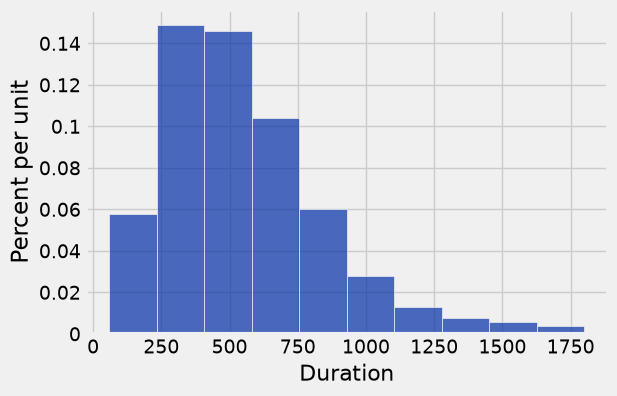

In [42]:
commute.hist('Duration')

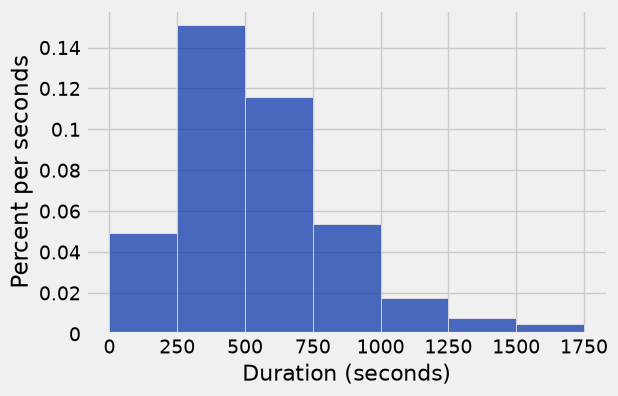

In [43]:
commute.hist('Duration', bins=np.arange(0, 1800, 250), unit='seconds')

# What percentage of trips are between 250 and 500 seconds

In [44]:
250 * 0.15

37.5

In [45]:
commute.show(1)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139


In [46]:
filt_duration = commute.where('Duration', are.between(250, 500)).num_rows

In [47]:
(filt_duration / commute.num_rows) * 100

37.6707843205871

In [48]:
# commute.hist('Duration', are.between(250, 500))

In [49]:
# Most common start station

In [50]:
arra = commute.column('Start Station')

In [51]:
# np.max(arra)

In [52]:
start_station = commute.group('Start Station')
start_station.sort('count', descending=True)

Start Station,count
San Francisco Caltrain (Townsend at 4th),14352
San Francisco Caltrain 2 (330 Townsend),13307
Harry Bridges Plaza (Ferry Building),9619
Temporary Transbay Terminal (Howard at Beale),8489
Townsend at 7th,8167
Steuart at Market,8109
2nd at Townsend,8013
Embarcadero at Sansome,7968
Market at 10th,6577
Market at Sansome,6265


In [53]:
# Num of trips between stations


In [54]:
com_group = commute.group({'Start Station', 'End Station'})

In [55]:
commute.pivot('Start Station', 'End Station')

End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,Civic Center BART (7th at Market),Clay at Battery,Commercial at Montgomery,Cowper at University,Davis at Jackson,Embarcadero at Bryant,Embarcadero at Folsom,Embarcadero at Sansome,Embarcadero at Vallejo,Evelyn Park and Ride,Franklin at Maple,Golden Gate at Polk,Grant Avenue at Columbus Avenue,Harry Bridges Plaza (Ferry Building),Howard at 2nd,Japantown,MLK Library,Market at 10th,Market at 4th,Market at Sansome,Mechanics Plaza (Market at Battery),Mezes Park,Mountain View Caltrain Station,Mountain View City Hall,Palo Alto Caltrain Station,Park at Olive,Paseo de San Antonio,Post at Kearny,Powell Street BART,Powell at Post (Union Square),Redwood City Caltrain Station,Redwood City Medical Center,Redwood City Public Library,Rengstorff Avenue / California Street,Ryland Park,SJSU - San Salvador at 9th,SJSU 4th at San Carlos,San Antonio Caltrain Station,San Antonio Shopping Center,San Francisco Caltrain (Townsend at 4th),San Francisco Caltrain 2 (330 Townsend),San Francisco City Hall,San Jose City Hall,San Jose Civic Center,San Jose Diridon Caltrain Station,San Mateo County Center,San Pedro Square,San Salvador at 1st,Santa Clara County Civic Center,Santa Clara at Almaden,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
2nd at Folsom,31,105,336,73,0,0,24,5,0,0,27,34,35,0,8,23,23,29,10,0,0,4,11,323,37,0,0,111,73,138,24,0,0,0,0,0,0,34,39,30,0,0,0,0,0,0,0,0,0,390,267,15,0,0,0,0,0,0,0,0,30,33,0,0,28,190,251,0,5,18
2nd at South Park,96,77,31,124,0,0,117,52,0,0,25,45,94,0,18,27,125,58,62,0,0,34,35,383,264,0,0,34,83,813,61,0,0,0,0,0,0,165,38,64,0,0,0,0,0,0,0,0,0,308,172,28,0,0,0,0,0,0,0,0,41,69,0,0,219,171,86,0,44,86
2nd at Townsend,310,80,104,51,0,0,351,212,0,0,52,179,81,0,222,248,377,254,193,0,0,16,187,1549,166,0,0,78,153,487,116,0,0,0,0,0,0,73,53,86,0,0,0,0,0,0,0,0,0,510,183,13,0,0,0,0,0,0,0,0,29,281,0,0,1446,404,280,0,44,83
5th at Howard,68,104,51,42,0,0,33,80,0,0,141,35,54,0,23,42,28,96,37,0,0,52,35,248,279,0,0,213,116,93,38,0,0,0,0,0,0,71,114,97,0,0,0,0,0,0,0,0,0,356,1042,33,0,0,0,0,0,0,0,0,61,46,0,0,122,469,118,0,27,168
Adobe on Almaden,0,0,0,0,5,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,2,0,0,0,0,0,0,0,0,0,19,0,0,0,0,0,0,0,2,5,10,0,0,0,0,0,11,12,151,0,17,3,3,4,0,0,10,0,0,0,0,0,0,0
Arena Green / SAP Center,0,0,0,0,6,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,4,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,0,19,2,4,0,0,0,0,0,3,16,5,0,27,9,12,117,0,0,5,0,0,0,0,0,0,0
Beale at Market,48,39,102,39,0,0,29,384,0,0,152,47,57,0,155,88,21,336,91,0,0,42,247,38,37,0,0,149,102,95,15,0,0,0,0,0,0,24,148,112,0,0,0,0,0,0,0,0,0,347,180,15,0,0,0,0,0,0,0,0,135,40,0,0,10,105,11,0,33,13
Broadway St at Battery St,34,53,174,83,0,0,647,74,0,0,39,170,134,0,99,135,39,168,27,0,0,3,40,104,29,0,0,21,50,205,145,0,0,0,0,0,0,83,32,114,0,0,0,0,0,0,0,0,0,349,263,5,0,0,0,0,0,0,0,0,7,71,0,0,192,428,24,0,38,22
California Ave Caltrain Station,0,0,0,0,0,0,0,0,24,1,0,0,0,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,96,20,0,0,0,0,0,0,0,4,0,0,0,7,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34,0,0
Castro Street and El Camino Real,0,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,558,22,0,0,0,0,0,0,0,0,0,4,0,0,0,2,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [56]:
# Average duration of trips between stations
commute.pivot('Start Station', 'End Station', 'Duration', np.mean)


End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,Civic Center BART (7th at Market),Clay at Battery,Commercial at Montgomery,Cowper at University,Davis at Jackson,Embarcadero at Bryant,Embarcadero at Folsom,Embarcadero at Sansome,Embarcadero at Vallejo,Evelyn Park and Ride,Franklin at Maple,Golden Gate at Polk,Grant Avenue at Columbus Avenue,Harry Bridges Plaza (Ferry Building),Howard at 2nd,Japantown,MLK Library,Market at 10th,Market at 4th,Market at Sansome,Mechanics Plaza (Market at Battery),Mezes Park,Mountain View Caltrain Station,Mountain View City Hall,Palo Alto Caltrain Station,Park at Olive,Paseo de San Antonio,Post at Kearny,Powell Street BART,Powell at Post (Union Square),Redwood City Caltrain Station,Redwood City Medical Center,Redwood City Public Library,Rengstorff Avenue / California Street,Ryland Park,SJSU - San Salvador at 9th,SJSU 4th at San Carlos,San Antonio Caltrain Station,San Antonio Shopping Center,San Francisco Caltrain (Townsend at 4th),San Francisco Caltrain 2 (330 Townsend),San Francisco City Hall,San Jose City Hall,San Jose Civic Center,San Jose Diridon Caltrain Station,San Mateo County Center,San Pedro Square,San Salvador at 1st,Santa Clara County Civic Center,Santa Clara at Almaden,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
2nd at Folsom,649.29,308.648,315.929,433.877,0,0,442.083,545.6,0,0,630.148,492.029,454.171,0,865.875,492.087,549.826,1174.31,775.8,0,0,789,625.909,475.452,202.73,0,0,694.847,430.616,292.188,350.333,0,0,0,0,0,0,382.471,546.692,511.033,0,0,0,0,0,0,0,0,0,473.831,479.906,1090.53,0,0,0,0,0,0,0,0,829.8,361.97,0,0,577.464,239.637,641.239,0,741,421.889
2nd at South Park,193.01,619.779,200.355,486.177,0,0,375.094,688.096,0,0,688.04,562.644,559.915,0,547.889,283.778,383.784,903.897,621.984,0,0,655.441,798.714,434.943,213.731,0,0,745.206,488.639,281.2,375.082,0,0,0,0,0,0,279.224,556.263,518.672,0,0,0,0,0,0,0,0,0,249.607,305.61,711.964,0,0,0,0,0,0,0,0,760.951,305.913,0,0,451.68,314.292,434.372,0,661.182,339.488
2nd at Townsend,290.4,318.325,821.635,612.078,0,0,513.598,767.575,0,0,761.962,796.045,808.395,0,704.176,362.117,484.729,920.992,828.42,0,0,992.125,891.642,618.077,370.669,0,0,851.885,685.654,502.634,673.94,0,0,0,0,0,0,657.548,913,716.14,0,0,0,0,0,0,0,0,0,266.273,273.77,1003.69,0,0,0,0,0,0,0,0,1048.79,410.399,0,0,557.47,434.582,464.054,0,1052.25,603.843
5th at Howard,394.279,626.846,628.353,752.762,0,0,593.333,862.875,0,0,374.227,678.114,559.037,0,746.217,624.952,619.714,1052.46,910.486,0,0,453.942,883.2,654.242,281.72,0,0,442.371,276.379,411.452,514.026,0,0,0,0,0,0,400.732,249.965,376.619,0,0,0,0,0,0,0,0,0,426.306,383.274,578.152,0,0,0,0,0,0,0,0,553.869,606.435,0,0,663.77,397.913,534.72,0,920.296,208.179
Adobe on Almaden,0,0,0,0,603,505.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,943.769,1005,0,0,0,0,0,0,0,0,0,473.316,0,0,0,0,0,0,0,493,925.2,523.3,0,0,0,0,0,573.455,334.833,300.815,0,362.647,792.667,1063,403.25,0,0,460,0,0,0,0,0,0,0
Arena Green / SAP Center,0,0,0,0,578.833,962.085,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1015.75,1054.25,0,0,0,0,0,0,0,0,0,737.857,0,0,0,0,0,0,0,704.053,916,788.25,0,0,0,0,0,572.333,811.562,983,0,362.296,1171.33,1136.92,229.632,0,0,745.8,0,0,0,0,0,0,0
Beale at Market,366.729,642.026,700,651.615,0,0,579.69,277.497,0,0,614.151,309.532,323.035,0,226.239,426.182,339.762,503.351,372.516,0,0,656.238,417.482,392.105,321.73,0,0,726.819,395.422,229.232,415.4,0,0,0,0,0,0,346.75,495.689,356.759,0,0,0,0,0,0,0,0,0,740.674,767.039,843.8,0,0,0,0,0,0,0,0,750.444,380.85,0,0,536,212.486,1050.73,0,424.515,476.692
Broadway St at Battery St,635.118,880.528,727.862,956.639,0,0,324.321,768.027,0,0,943.821,235.9

In [57]:
# Shortest trip between each pair of stations start end shortest trip
# commute_min = commute.column('Duration')
com_group = commute.select('Start Station', 'End Station', 'Duration')
# cones.group(['Flavor', 'Color'], np.mean)



In [58]:
com_group

Start Station,End Station,Duration
Harry Bridges Plaza (Ferry Building),San Francisco Caltrain (Townsend at 4th),765
San Antonio Shopping Center,Mountain View City Hall,1036
Post at Kearny,2nd at South Park,307
San Jose City Hall,San Salvador at 1st,409
Embarcadero at Folsom,Embarcadero at Sansome,789
Yerba Buena Center of the Arts (3rd @ Howard),San Francisco Caltrain (Townsend at 4th),293
Embarcadero at Folsom,Embarcadero at Sansome,896
Embarcadero at Sansome,Steuart at Market,255
Beale at Market,Temporary Transbay Terminal (Howard at Beale),126
Post at Kearny,South Van Ness at Market,932


In [59]:
shortest = com_group.group(['Start Station', 'End Station'], min)
shortest

Start Station,End Station,Duration min
2nd at Folsom,2nd at Folsom,61
2nd at Folsom,2nd at South Park,61
2nd at Folsom,2nd at Townsend,137
2nd at Folsom,5th at Howard,215
2nd at Folsom,Beale at Market,219
2nd at Folsom,Broadway St at Battery St,412
2nd at Folsom,Civic Center BART (7th at Market),456
2nd at Folsom,Clay at Battery,280
2nd at Folsom,Commercial at Montgomery,275
2nd at Folsom,Davis at Jackson,396


In [60]:
# Find the 5 stations closest to Civic Center BART by minimum trip time

In [61]:
shortest = com_group.group(['Start Station', 'End Station'], min)

In [62]:
# filt_duration = commute.where('Start Station', are.equal_to('Civic Center BART (7th at Market)'))
# filt_duration2 = commute.where('End Station', are.equal_to('Civic Center BART (7th at Market)'))

# # bar = com_group.('')
# # bart = com_group.('Start Station', 'Civic Center BART (7th at Market)', 'End ')

# filt_duration.sort('Duration', descending=False)

# # new = Table.append(filt_duration, filt_duration2)
# # # new = Table.join(filt_duration, None, filt_duration2) 
# # new = Table.with_rows(filt_duration, filt_duration2)

In [63]:
# sorted = new.sort('Duration', descending=False)

In [64]:
stations = Table().read_table('data/station.csv')

In [65]:
# Stations in San Francisco 

stations = stations.drop(4, 6)
stations

station_id,name,lat,long,landmark
2,San Jose Diridon Caltrain Station,37.3297,-121.902,San Jose
3,San Jose Civic Center,37.3307,-121.889,San Jose
4,Santa Clara at Almaden,37.334,-121.895,San Jose
5,Adobe on Almaden,37.3314,-121.893,San Jose
6,San Pedro Square,37.3367,-121.894,San Jose
7,Paseo de San Antonio,37.3338,-121.887,San Jose
8,San Salvador at 1st,37.3302,-121.886,San Jose
9,Japantown,37.3487,-121.895,San Jose
10,San Jose City Hall,37.3374,-121.887,San Jose
11,MLK Library,37.3359,-121.886,San Jose


In [66]:
san_fr = stations.where('landmark', 'San Francisco')
san_fr_map_data = (san_fr.select('lat', 'long', 'name').relabeled('name', 'labels'))

In [67]:
san_fr_map_data.show(3)

lat,long,labels
37.795,-122.4,Clay at Battery
37.7973,-122.398,Davis at Jackson
37.7942,-122.403,Commercial at Montgomery


In [68]:
Marker.map_table(san_fr_map_data)

In [69]:
# Map all staitons within 4 mins of Civic Center

In [70]:
cc = 'Civic Center BART (7th at Market)'
from_cc = shortest.where('Start Station', cc).sort('Duration min')

In [71]:
close_cc = from_cc.where('Duration min', are.below(4 * 60))

In [72]:
close_markers = (san_fr_map_data.join('labels', close_cc, 'End Station').select('lat', 'long', 'labels'))
Marker.map_table(close_markers)

In [73]:
commute.where('Duration', are.below(500)).num_rows

100021

In [74]:
commute.column('Duration') < 500

array([False, False,  True, ..., False, False,  True], shape=(200033,))

In [75]:
sum(commute.column('Duration')) >= 250

np.True_

array([False, False,  True, ..., False, False,  True], shape=(200033,))

In [76]:
sum((commute.column('Duration') < 500) & (commute.column('Duration') >= 250))

np.int64(75354)

## If statemenet

In [86]:
def sign(x):
    """Determines the sign(+/-) of a numeric input"""
    if type(x) != type(1):
        return 'invalid'
        
    if x > 0:
        return "Positive"
    elif x < 0:
        return "Negatitve"
    elif x == 0:
        return "0"
    

sign(99)

'Positive'

In [88]:
sum(np.arange(4) <= 1) * -2

np.int64(-4)

In [87]:
np.arange(4)

array([0, 1, 2, 3])

## For Loops

In [98]:
for i in np.arange(5):
    print('I am counting. I am at', i + 1)

I am counting. I am at 1
I am counting. I am at 2
I am counting. I am at 3
I am counting. I am at 4
I am counting. I am at 5


In [99]:
faculty = np.array(['John', 'James', 'Peter'])

for name in faculty:
    print(name)

John
James
Peter


In [101]:
arr = np.arange(4)
arr2 = np.arange(5)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 4)